# 🏦 Credit Card Fraud Detection
## Machine Learning Mini Lab — All 10 Experiments

This notebook covers the complete **Machine Learning Development Life Cycle (MLDLC)** applied to a Credit Card Fraud Detection problem.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
from datetime import datetime

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---
## 🔬 Experiment 1: Problem Definition & Dataset Selection
*(MLDLC Step 1)*

### Objective
Define the ML problem clearly and understand what we are trying to achieve.

### Problem Statement
Credit card fraud is a major financial threat. Banks and payment companies need to **automatically identify whether a transaction is fraudulent or legitimate** to protect customers.

| Item | Details |
|---|---|
| **Real-world problem** | Detecting fraudulent credit card transactions |
| **Objective** | Build a classifier that predicts if a transaction is fraud (1) or not (0) |
| **Input Features (X)** | Age, Gender, Transaction Amount, Merchant Category, City, Transaction Time, International Transaction flag, Card Present flag, Failed Attempts |
| **Target Variable (Y)** | `Fraud` — binary: 0 = Legitimate, 1 = Fraudulent |
| **Dataset** | Synthetic credit card transactions (1,000 rows, 13 columns) |

### Why Machine Learning?
Manual rule-based systems cannot handle the complexity and volume of modern transactions. ML learns hidden patterns from historical data and generalizes to new transactions.

---

## 🔬 Experiment 2: Dataset Understanding & Structure
*(MLDLC Step 2)*

### Objective
Load the dataset and understand its structure — rows, columns, data types, features vs. target.

In [2]:
# UPDATE THIS PATH to your local CSV file
DATA_PATH = "/kaggle/input/datasets/prakhartiwari077/fraud-detection/credit_card_fraud_detection_dataset.csv"

try:
    data = pd.read_csv(DATA_PATH)
    print("✅ Dataset loaded successfully!")
except FileNotFoundError:
    print("❌ Dataset file not found. Please check DATA_PATH.")
    raise

print(f"\n📦 Rows: {data.shape[0]}  |  Columns: {data.shape[1]}")
data.info()
display(data.head())

✅ Dataset loaded successfully!

📦 Rows: 1000  |  Columns: 13
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Transaction_ID             1000 non-null   object 
 1   Cardholder_Name            1000 non-null   object 
 2   Age                        1000 non-null   int64  
 3   Gender                     1000 non-null   object 
 4   Transaction_Amount         1000 non-null   float64
 5   Merchant_Name              1000 non-null   object 
 6   Merchant_Category          1000 non-null   object 
 7   City                       1000 non-null   object 
 8   Transaction_Time           1000 non-null   object 
 9   International_Transaction  1000 non-null   int64  
 10  Card_Present               1000 non-null   int64  
 11  Failed_Attempts            1000 non-null   int64  
 12  Fraud                      1000 non-null   i

,Transaction_ID,Cardholder_Name,Age,Gender,Transaction_Amount,Merchant_Name,Merchant_Category,City,Transaction_Time,International_Transaction,Card_Present,Failed_Attempts,Fraud
0,TXN1000,Marie Harris,56,Male,3984.75,Smith Group,Grocery,Chennai,2025-08-09 17:33:16,1,0,4,1
1,TXN1001,Philip Davis,38,Male,788.53,Solomon Group,Travel,Chennai,2025-10-04 17:30:16,0,0,4,1
2,TXN1002,Riley Kim,53,Female,722.91,Ayers Group,Grocery,Delhi,2025-12-27 05:48:16,0,0,1,0
3,TXN1003,Jeffrey Barrett,41,Male,4163.89,Smith-Richard,Online Shopping,Pune,2025-07-18 01:41:16,0,0,4,1
4,TXN1004,Sara Hogan,50,Female,1528.17,"Gonzalez, Phillips and Reese",Food,Gurgaon,2026-04-15 16:16:16,1,0,0,0


── Column Data Types ─────────────────────────────────
Transaction_ID                object
Cardholder_Name               object
Age                            int64
Gender                        object
Transaction_Amount           float64
Merchant_Name                 object
Merchant_Category             object
City                          object
Transaction_Time              object
International_Transaction      int64
Card_Present                   int64
Failed_Attempts                int64
Fraud                          int64
dtype: object

── Features (X) vs Target (Y) ───────────────────────
Input Features (X) : ['Transaction_ID', 'Cardholder_Name', 'Age', 'Gender', 'Transaction_Amount', 'Merchant_Name', 'Merchant_Category', 'City', 'Transaction_Time', 'International_Transaction', 'Card_Present', 'Failed_Attempts']
Target Variable (Y): 'Fraud' → 0 = Legitimate, 1 = Fraudulent

── Target Class Distribution ────────────────────────
Fraud
0    509
1    491
Name: count, dtype: int64


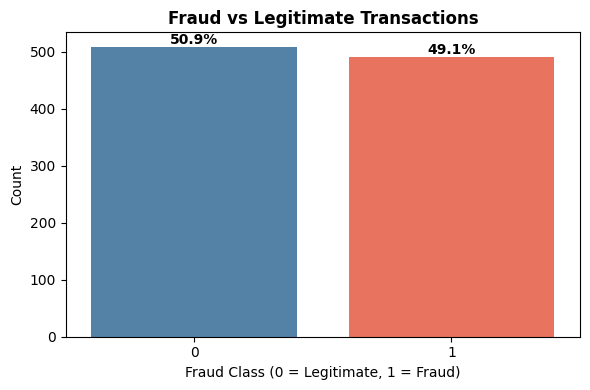

In [3]:
print("── Column Data Types ─────────────────────────────────")
print(data.dtypes)

print("\n── Features (X) vs Target (Y) ───────────────────────")
feature_cols = [c for c in data.columns if c != 'Fraud']
print(f"Input Features (X) : {feature_cols}")
print("Target Variable (Y): 'Fraud' → 0 = Legitimate, 1 = Fraudulent")

print("\n── Target Class Distribution ────────────────────────")
print(data['Fraud'].value_counts())
print(data['Fraud'].value_counts(normalize=True).mul(100).round(2).to_string())
print(f"\nFraud Rate: {data['Fraud'].mean()*100:.2f}%")

plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Fraud', data=data, palette=['steelblue', 'tomato'])
total = len(data)
for p in ax.patches:
    ax.annotate(f'{100 * p.get_height() / total:.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontweight='bold')
plt.title("Fraud vs Legitimate Transactions", fontweight='bold')
plt.xlabel("Fraud Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [4]:
print("── Statistical Summary ───────────────────────────────")
summary = data.describe(include='all').T
summary['missing_values'] = data.isnull().sum()
display(summary)

── Statistical Summary ───────────────────────────────


,count,unique,top,freq,mean,std,min,25%,50%,75%,max,missing_values
Transaction_ID,1000,1000,TXN1999,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
Cardholder_Name,1000,992,Robert Williams,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
Age,1000.0,NaN,NaN,NaN,44.208,14.697645,18.0,32.0,45.0,57.0,69.0,0
Gender,1000,2,Male,503,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
Transaction_Amount,1000.0,NaN,NaN,NaN,2488.78998,1476.600993,11.19,1149.6825,2500.4,3780.315,4998.59,0
Merchant_Name,1000,972,Smith Group,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
Merchant_Category,1000,9,Online Shopping,138,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
City,1000,6,Mumbai,194,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
Transaction_Time,1000,999,2026-02-27 12:52:16,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
International_Transaction,1000.0,NaN,NaN,NaN,0.518,0.499926,0.0,0.0,1.0,1.0,1.0,0


**💡 Key Observations:**
- **1,000 rows, 13 columns** — manageable size.
- **Nearly balanced**: ~49% fraud, ~51% legitimate.
- Mix of numeric and categorical columns.
- `Transaction_ID`, `Cardholder_Name`, `Merchant_Name` are identifiers — not useful as features.

---

## 🔬 Experiment 3: Problem Type Identification
*(MLDLC Step 2 continued)*

### Objective
Identify the exact type of ML problem we are solving.

In [5]:
print("=" * 55)
print(" PROBLEM TYPE ANALYSIS")
print("=" * 55)

print("\n1️⃣  Supervised vs Unsupervised?")
print("   → SUPERVISED — labelled target column 'Fraud' exists.")

print("\n2️⃣  Classification vs Regression?")
print("   → CLASSIFICATION — target is categorical:")
print(f"     Unique values: {sorted(data['Fraud'].unique())}  (0 = Legit, 1 = Fraud)")

print("\n3️⃣  Binary vs Multi-class?")
print("   → BINARY CLASSIFICATION — only 2 classes.")

print(f"\n4️⃣  Balanced vs Imbalanced?")
print(f"   → Fraud rate is {data['Fraud'].mean()*100:.2f}% — well balanced.")

print("\n5️⃣  Key Evaluation Metrics?")
print("   → Recall, Precision, F1-score, ROC-AUC")
print("     (Accuracy alone is misleading for fraud detection.)")

print("\n" + "=" * 55)
print(" CONCLUSION: Supervised Binary Classification")
print("=" * 55)
print("  Algorithms : Logistic Regression, Decision Tree, Random Forest")
print("  Priority   : High Recall — missing fraud is most costly.")

 PROBLEM TYPE ANALYSIS

1️⃣  Supervised vs Unsupervised?
   → SUPERVISED — labelled target column 'Fraud' exists.

2️⃣  Classification vs Regression?
   → CLASSIFICATION — target is categorical:
     Unique values: [np.int64(0), np.int64(1)]  (0 = Legit, 1 = Fraud)

3️⃣  Binary vs Multi-class?
   → BINARY CLASSIFICATION — only 2 classes.

4️⃣  Balanced vs Imbalanced?
   → Fraud rate is 49.10% — well balanced.

5️⃣  Key Evaluation Metrics?
   → Recall, Precision, F1-score, ROC-AUC
     (Accuracy alone is misleading for fraud detection.)

 CONCLUSION: Supervised Binary Classification
  Algorithms : Logistic Regression, Decision Tree, Random Forest
  Priority   : High Recall — missing fraud is most costly.


**💡 Justification:**
- **Supervised**: Labelled historical data is available.
- **Classification**: Target is a discrete category, not a number.
- **Binary**: Only two outcomes — fraud or legitimate.

---

## 🔬 Experiment 4: Data Cleaning
*(MLDLC Step 3 — Part 1)*

### Objective
Handle missing values, duplicates, outliers, and invalid entries.

In [6]:
print("=" * 55)
print(" DATA CLEANING")
print("=" * 55)

# Missing Values
print("\n── Missing Values ────────────────────────────────────")
missing = data.isna().sum()
missing_nonzero = missing[missing > 0]
if len(missing_nonzero) == 0:
    print("✅ No missing values found.")
else:
    print(missing_nonzero)
    print((missing_nonzero / len(data) * 100).round(2).rename("Missing %"))
print(f"Total missing: {data.isna().sum().sum()}")

# Duplicates
print("\n── Duplicate Rows ────────────────────────────────────")
duplicates = data.duplicated().sum()
if duplicates > 0:
    data = data.drop_duplicates(keep='first').reset_index(drop=True)
    print(f"✅ Removed {duplicates} duplicate rows. New shape: {data.shape}")
else:
    print(f"✅ No duplicates found. (Rows: {len(data)})")

 DATA CLEANING

── Missing Values ────────────────────────────────────
✅ No missing values found.
Total missing: 0

── Duplicate Rows ────────────────────────────────────
✅ No duplicates found. (Rows: 1000)


── Outlier Detection (IQR Method) ────────────────────
  Age: 0 outliers clipped → [-5.50, 94.50]
  Transaction_Amount: 0 outliers clipped → [-2796.27, 7726.26]
  Failed_Attempts: 0 outliers clipped → [-3.50, 8.50]

✅ Outliers capped using IQR method.


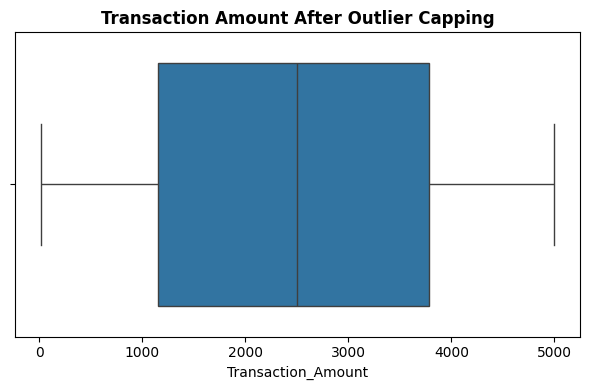


── Invalid Value Checks ──────────────────────────────
✅ No invalid values found.

Cleaned Dataset Shape: (1000, 13)


In [7]:
# Outlier Detection & Capping (IQR Method)
print("── Outlier Detection (IQR Method) ────────────────────")

numeric_cols = ['Age', 'Transaction_Amount', 'Failed_Attempts']
for col in numeric_cols:
    Q1, Q3 = data[col].quantile(0.25), data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = ((data[col] < lower) | (data[col] > upper)).sum()
    data[col] = data[col].clip(lower, upper)
    print(f"  {col}: {outliers} outliers clipped → [{lower:.2f}, {upper:.2f}]")

print("\n✅ Outliers capped using IQR method.")

plt.figure(figsize=(6, 4))
sns.boxplot(x=data['Transaction_Amount'])
plt.title("Transaction Amount After Outlier Capping", fontweight='bold')
plt.tight_layout()
plt.show()

# Invalid Value Checks
print("\n── Invalid Value Checks ──────────────────────────────")
errors = []
if data['Age'].min() < 0:                                   errors.append("Negative age!")
if data['Transaction_Amount'].min() < 0:                    errors.append("Negative amount!")
if not set(data['Fraud'].unique()).issubset({0, 1}):         errors.append("Invalid Fraud label!")

if errors:
    for e in errors: print("  ❌", e)
else:
    print("✅ No invalid values found.")
print(f"\nCleaned Dataset Shape: {data.shape}")

**💡 What we did:**
- **Missing values**: None found. If present → fill numeric with median, categorical with mode.
- **Duplicates**: None found. Duplicates cause overfitting.
- **Outliers**: IQR capping — preserves row count while limiting extremes.
- **Invalid values**: Logical constraints verified.

---

## 🔬 Experiment 5: Data Preprocessing
*(MLDLC Step 3 — Part 2)*

### Objective
Encode categories, extract features from datetime, and scale numeric columns.

In [8]:
print("=" * 55)
print(" DATA PREPROCESSING")
print("=" * 55)

# Drop identifier columns
cols_to_drop = ['Transaction_ID', 'Cardholder_Name', 'Merchant_Name']
data_clean = data.drop(columns=cols_to_drop, errors='ignore')
print("✅ Dropped:", cols_to_drop)
print(f"Shape: {data_clean.shape}")

 DATA PREPROCESSING
✅ Dropped: ['Transaction_ID', 'Cardholder_Name', 'Merchant_Name']
Shape: (1000, 10)


In [9]:
# Feature Engineering from Transaction_Time
data_clean['Transaction_Time'] = pd.to_datetime(data_clean['Transaction_Time'], errors='coerce')
data_clean['Hour']      = data_clean['Transaction_Time'].dt.hour
data_clean['Month']     = data_clean['Transaction_Time'].dt.month
data_clean['DayOfWeek'] = data_clean['Transaction_Time'].dt.dayofweek
data_clean['IsWeekend'] = (data_clean['DayOfWeek'] >= 5).astype(int)
data_clean['IsNight']   = (data_clean['Hour'] < 6).astype(int)
data_clean.drop(columns=['Transaction_Time'], inplace=True)
print("✅ Extracted: Hour, Month, DayOfWeek, IsWeekend, IsNight")

✅ Extracted: Hour, Month, DayOfWeek, IsWeekend, IsNight


In [10]:
# Encode Categorical Features
# Binary: Gender
data_clean['Gender'] = data_clean['Gender'].map({'Male': 0, 'Female': 1})

# One-Hot: Merchant_Category, City
data_clean = pd.get_dummies(data_clean, columns=['Merchant_Category', 'City'], drop_first=True)

# Convert bool columns to int
bool_cols = data_clean.select_dtypes(include='bool').columns
data_clean[bool_cols] = data_clean[bool_cols].astype(int)

print("✅ Gender: Male=0, Female=1")
print("✅ One-Hot Encoding applied to Merchant_Category and City")
print(f"Dataset shape after encoding: {data_clean.shape}")
display(data_clean.head())

✅ Gender: Male=0, Female=1
✅ One-Hot Encoding applied to Merchant_Category and City
Dataset shape after encoding: (1000, 25)


,Age,Gender,Transaction_Amount,International_Transaction,Card_Present,Failed_Attempts,Fraud,Hour,Month,DayOfWeek,...,Merchant_Category_Fuel,Merchant_Category_Grocery,Merchant_Category_Healthcare,Merchant_Category_Online Shopping,Merchant_Category_Travel,City_Chennai,City_Delhi,City_Gurgaon,City_Mumbai,City_Pune
0,56,0,3984.75,1,0,4,1,17,8,5,...,0,1,0,0,0,1,0,0,0,0
1,38,0,788.53,0,0,4,1,17,10,5,...,0,0,0,0,1,1,0,0,0,0
2,53,1,722.91,0,0,1,0,5,12,5,...,0,1,0,0,0,0,1,0,0,0
3,41,0,4163.89,0,0,4,1,1,7,4,...,0,0,0,1,0,0,0,0,0,1
4,50,1,1528.17,1,0,0,0,16,4,2,...,0,0,0,0,0,0,0,1,0,0


In [11]:
# Features / Target Split
X = data_clean.drop(columns=['Fraud'])
y = data_clean['Fraud']

print(f"Features (X): {X.shape}  |  Target (y): {y.shape}")

# Train-Test Split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"\nTrain: {X_train.shape}  |  Test: {X_test.shape}")

# Scale numeric columns (fit on train only — no data leakage)
scale_cols = ['Age', 'Transaction_Amount', 'Failed_Attempts', 'Hour']
X_train = X_train.copy()
X_test  = X_test.copy()
X_train[scale_cols] = X_train[scale_cols].fillna(X_train[scale_cols].median())
X_test[scale_cols]  = X_test[scale_cols].fillna(X_train[scale_cols].median())

scaler = StandardScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols]  = scaler.transform(X_test[scale_cols])
print("\n✅ StandardScaler applied (fit on train only — no leakage).")

Features (X): (1000, 24)  |  Target (y): (1000,)

Train: (800, 24)  |  Test: (200, 24)

✅ StandardScaler applied (fit on train only — no leakage).


**💡 What we did:**
- **Dropped IDs**: No predictive value.
- **DateTime → numeric features**: Hour/DayOfWeek capture time-based fraud patterns.
- **Gender → binary (0/1)**: Only 2 values, no need for OHE.
- **OHE for City/Category**: Nominal features with no ordering. `drop_first=True` avoids the dummy variable trap.
- **StandardScaler**: Prevents large-magnitude features from dominating gradient-based models.

---

## 🔬 Experiment 6: Exploratory Data Analysis (EDA)
*(MLDLC Step 4)*

### Objective
Visualize patterns to understand what drives fraud.

 EXPLORATORY DATA ANALYSIS


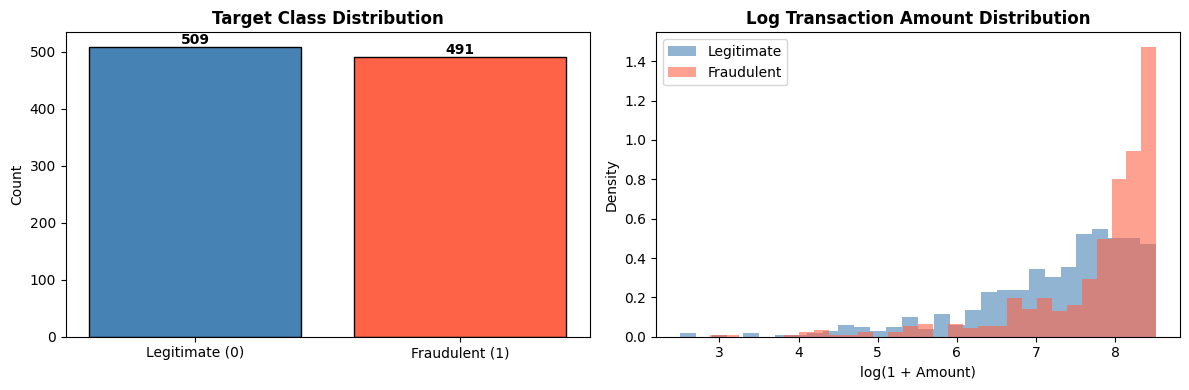

In [12]:
print("=" * 55)
print(" EXPLORATORY DATA ANALYSIS")
print("=" * 55)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class Distribution
counts = y.value_counts()
axes[0].bar(['Legitimate (0)', 'Fraudulent (1)'], counts.values,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Target Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Log Transaction Amount Distribution
legit = data[data['Fraud'] == 0]['Transaction_Amount']
fraud = data[data['Fraud'] == 1]['Transaction_Amount']
axes[1].hist(np.log1p(legit), bins=30, alpha=0.6, density=True, label='Legitimate', color='steelblue')
axes[1].hist(np.log1p(fraud), bins=30, alpha=0.6, density=True, label='Fraudulent', color='tomato')
axes[1].set_title('Log Transaction Amount Distribution', fontweight='bold')
axes[1].set_xlabel('log(1 + Amount)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

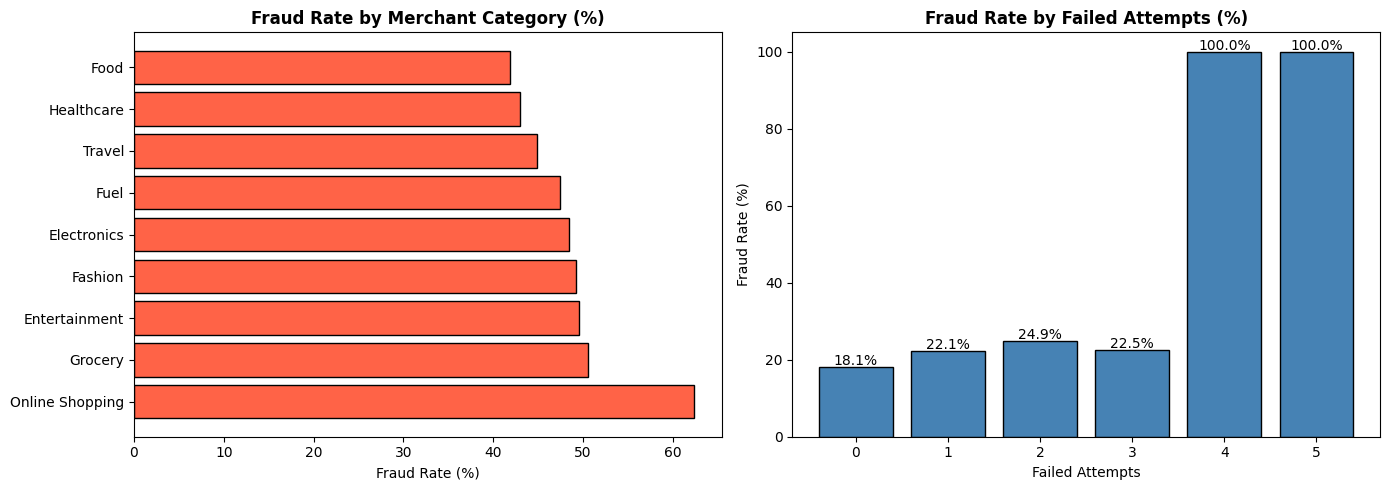

In [13]:
# Fraud Rate by Merchant Category & Failed Attempts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fraud_by_cat = data.groupby('Merchant_Category')['Fraud'].mean().sort_values(ascending=False)
axes[0].barh(fraud_by_cat.index, fraud_by_cat.values * 100, edgecolor='black', color='tomato')
axes[0].set_title('Fraud Rate by Merchant Category (%)', fontweight='bold')
axes[0].set_xlabel('Fraud Rate (%)')

fraud_by_attempts = data.groupby('Failed_Attempts')['Fraud'].mean() * 100
axes[1].bar(fraud_by_attempts.index, fraud_by_attempts.values, edgecolor='black', color='steelblue')
axes[1].set_title('Fraud Rate by Failed Attempts (%)', fontweight='bold')
axes[1].set_xlabel('Failed Attempts')
axes[1].set_ylabel('Fraud Rate (%)')
for i, v in enumerate(fraud_by_attempts.values):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()

── Descriptive Statistics ────────────────────────────


,Age,Gender,Transaction_Amount,International_Transaction,Card_Present,Failed_Attempts,Fraud,Hour,Month,DayOfWeek,...,Merchant_Category_Fuel,Merchant_Category_Grocery,Merchant_Category_Healthcare,Merchant_Category_Online Shopping,Merchant_Category_Travel,City_Chennai,City_Delhi,City_Gurgaon,City_Mumbai,City_Pune
count,1000.00,1000.0,1000.00,1000.00,1000.0,1000.00,1000.00,1000.00,1000.00,1000.00,...,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,44.21,0.5,2488.79,0.52,0.5,2.54,0.49,11.44,6.52,3.02,...,0.12,0.09,0.11,0.14,0.09,0.16,0.16,0.16,0.19,0.15
std,14.70,0.5,1476.60,0.50,0.5,1.71,0.50,6.81,3.41,1.94,...,0.32,0.29,0.31,0.35,0.28,0.37,0.36,0.37,0.40,0.36
min,18.00,0.0,11.19,0.00,0.0,0.00,0.00,0.00,1.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,32.00,0.0,1149.68,0.00,0.0,1.00,0.00,6.00,4.00,1.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,45.00,0.0,2500.40,1.00,0.0,3.00,0.00,11.00,7.00,3.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,57.00,1.0,3780.32,1.00,1.0,4.00,1.00,17.00,9.00,5.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
max,69.00,1.0,4998.59,1.00,1.0,5.00,1.00,23.00,12.00,6.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


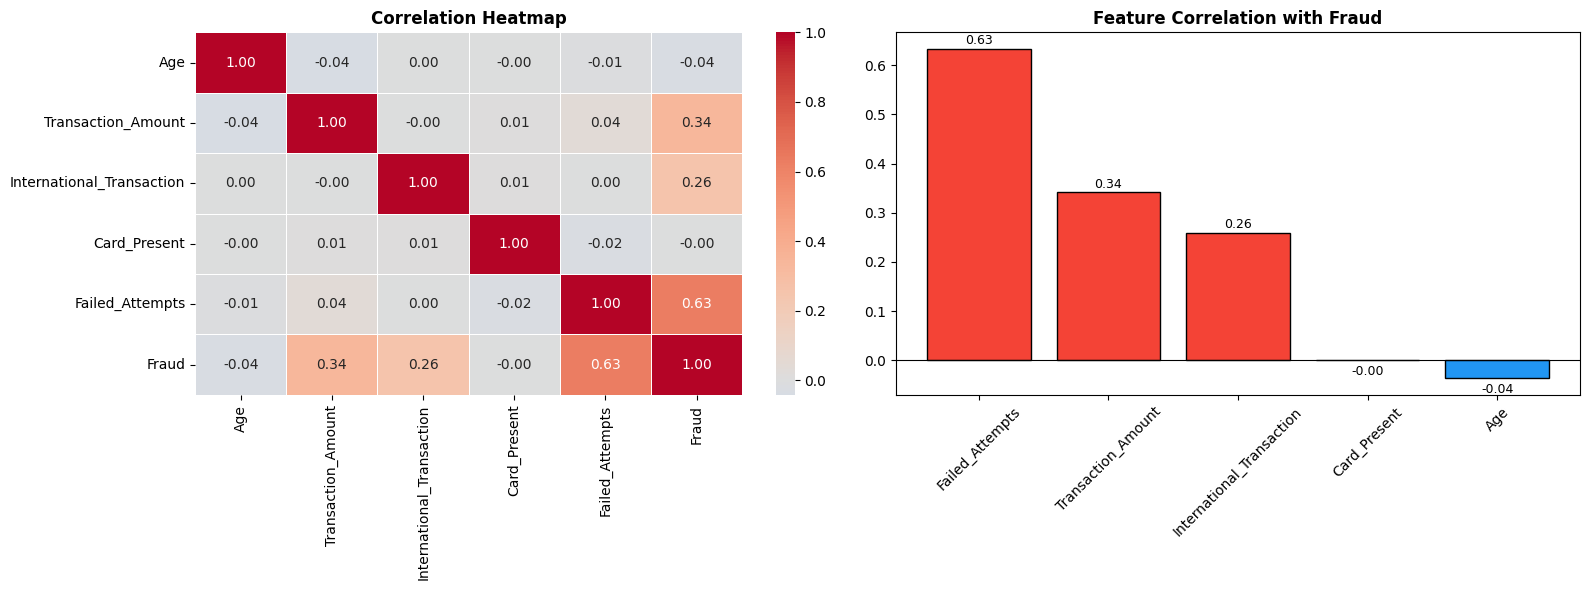

In [14]:
# Descriptive Statistics
print("── Descriptive Statistics ────────────────────────────")
display(data_clean.select_dtypes(include=np.number).describe().round(2))

# Correlation Heatmap + Bar Chart
key_cols = [c for c in ['Age', 'Transaction_Amount', 'International_Transaction',
                         'Card_Present', 'Failed_Attempts', 'Fraud'] if c in data_clean.columns]
corr_matrix = data_clean[key_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, center=0, ax=axes[0])
axes[0].set_title('Correlation Heatmap', fontweight='bold')

corr_with_fraud = corr_matrix['Fraud'].drop('Fraud').sort_values(ascending=False)
colors = ['#F44336' if v > 0 else '#2196F3' for v in corr_with_fraud.values]
axes[1].bar(corr_with_fraud.index, corr_with_fraud.values, color=colors, edgecolor='black')
for i, v in enumerate(corr_with_fraud.values):
    axes[1].text(i, v + (0.01 if v >= 0 else -0.03), f"{v:.2f}", ha='center', fontsize=9)
axes[1].set_title('Feature Correlation with Fraud', fontweight='bold')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**💡 Key Insights:**
- **Failed_Attempts** is the strongest predictor of fraud.
- **International transactions** and **card not present** (Card_Present=0) also associate with fraud.
- Transaction amount alone does not cleanly separate fraud from legitimate transactions.

---

## 🔬 Experiment 7: Feature Selection & Engineering
*(MLDLC Step 5)*

### Objective
Select the most informative features to reduce noise and improve model performance.

 FEATURE SELECTION

── Feature Correlation with Fraud (Train Data) ──────


,Correlation with Fraud
Failed_Attempts,0.648365
Transaction_Amount,0.334283
International_Transaction,0.272946
Merchant_Category_Online Shopping,0.099362
City_Chennai,0.068407
Age,-0.059417
Merchant_Category_Food,-0.050893
DayOfWeek,-0.049065
City_Mumbai,-0.047507
IsWeekend,-0.042528


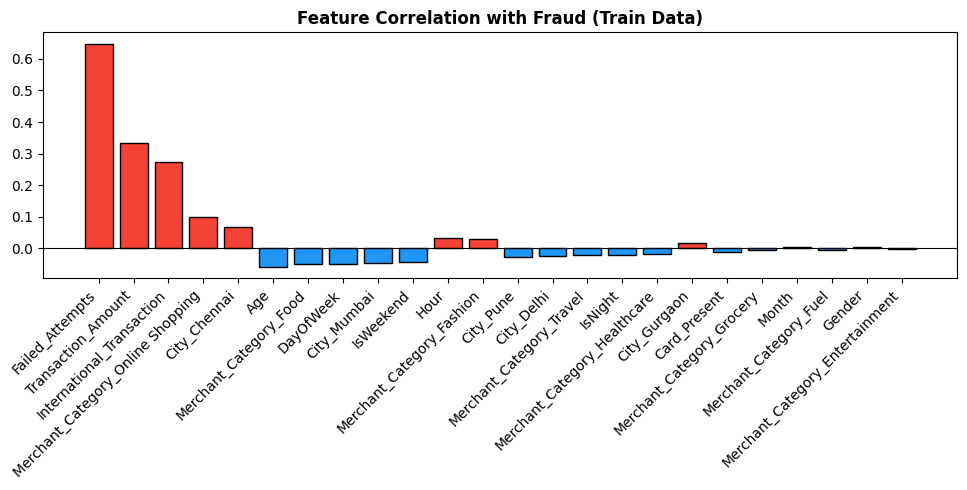

In [15]:
print("=" * 55)
print(" FEATURE SELECTION")
print("=" * 55)

# Correlation-based ranking (train data only)
corr_with_target = X_train.corrwith(y_train)
corr_sorted = corr_with_target.reindex(corr_with_target.abs().sort_values(ascending=False).index)

print("\n── Feature Correlation with Fraud (Train Data) ──────")
display(corr_sorted.to_frame(name="Correlation with Fraud"))

plt.figure(figsize=(10, 5))
colors = ['#F44336' if v > 0 else '#2196F3' for v in corr_sorted.values]
plt.bar(corr_sorted.index, corr_sorted.values, color=colors, edgecolor='black')
plt.title("Feature Correlation with Fraud (Train Data)", fontweight='bold')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

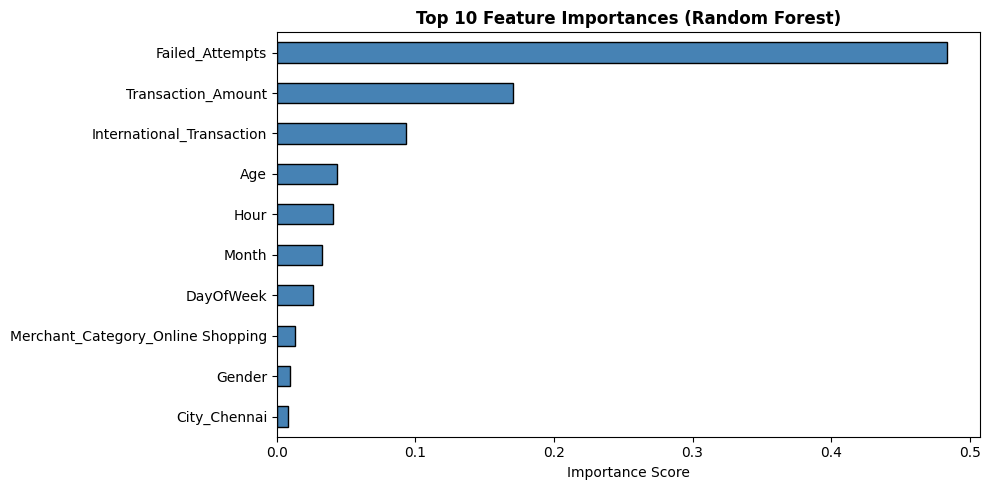


── Top 10 Features ──────────────────────────────────
Failed_Attempts                      0.4834
Transaction_Amount                   0.1702
International_Transaction            0.0932
Age                                  0.0436
Hour                                 0.0401
Month                                0.0323
DayOfWeek                            0.0261
Merchant_Category_Online Shopping    0.0132
Gender                               0.0094
City_Chennai                         0.0081
dtype: float64


In [16]:
# Random Forest Feature Importance
rf_fs = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_fs.fit(X_train, y_train)

importances = pd.Series(rf_fs.feature_importances_, index=X_train.columns)
top10 = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
top10.sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.title("Top 10 Feature Importances (Random Forest)", fontweight='bold')
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("\n── Top 10 Features ──────────────────────────────────")
print(top10.round(4))

In [17]:
# Chi-Square SelectKBest (applied on train only)
print("\n── Chi-Square Feature Selection ─────────────────────")

X_train_abs = X_train.abs()   # chi2 requires non-negative values
k = min(10, X_train.shape[1])
selector = SelectKBest(score_func=chi2, k=k)
selector.fit(X_train_abs, y_train)

selected_features = X_train.columns[selector.get_support()].tolist()
X_train_selected = X_train[selected_features].copy()
X_test_selected  = X_test[selected_features].copy()

print(f"✅ Selected {k} features:")
for f in selected_features:
    print(f"  • {f}")

print(f"\nX_train_selected: {X_train_selected.shape}")
print(f"X_test_selected : {X_test_selected.shape}")


── Chi-Square Feature Selection ─────────────────────
✅ Selected 10 features:
  • Transaction_Amount
  • International_Transaction
  • Failed_Attempts
  • DayOfWeek
  • IsWeekend
  • Merchant_Category_Fashion
  • Merchant_Category_Food
  • Merchant_Category_Online Shopping
  • City_Chennai
  • City_Mumbai

X_train_selected: (800, 10)
X_test_selected : (200, 10)


**💡 What we did:**
- **Correlation filtering**: Highlights linearly related features — computed on train data only.
- **Random Forest importance**: Captures non-linear relationships without data leakage.
- **Chi-Square (SelectKBest)**: Statistical test; selects the top-k most relevant features.

---

## 🔬 Experiment 8: Model Training & Selection
*(MLDLC Steps 6 & 7)*

### Objective
Train three ML models on the selected features and compare their performance.

In [18]:
print("=" * 55)
print(" MODEL TRAINING")
print("=" * 55)

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
    "Decision Tree"      : DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
    "Random Forest"      : RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, class_weight='balanced')
}

results = {}

for name, model in models.items():
    model.fit(X_train_selected, y_train)
    y_pred = model.predict(X_test_selected)

    results[name] = {
        "model"    : model,
        "accuracy" : accuracy_score(y_test, y_pred),
        "recall"   : recall_score(y_test, y_pred, zero_division=0),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "f1"       : f1_score(y_test, y_pred, zero_division=0),
        "roc_auc"  : roc_auc_score(y_test, y_pred)
    }

    print(f"\n{name}")
    for metric in ["accuracy", "recall", "precision", "f1", "roc_auc"]:
        print(f"  {metric:<12}: {results[name][metric]:.4f}")

 MODEL TRAINING

Logistic Regression
  accuracy    : 0.8100
  recall      : 0.8367
  precision   : 0.7885
  f1          : 0.8119
  roc_auc     : 0.8105

Decision Tree
  accuracy    : 0.9950
  recall      : 0.9898
  precision   : 1.0000
  f1          : 0.9949
  roc_auc     : 0.9949

Random Forest
  accuracy    : 0.9950
  recall      : 0.9898
  precision   : 1.0000
  f1          : 0.9949
  roc_auc     : 0.9949


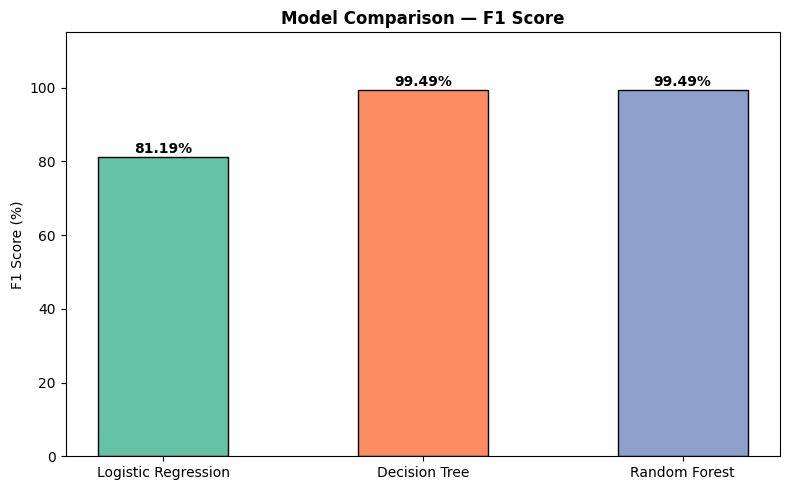

🏆 Best Model (F1): Decision Tree


In [19]:
# Bar Chart — Model Comparison (F1)
names  = list(results.keys())
scores = [results[n]["f1"] * 100 for n in names]

plt.figure(figsize=(8, 5))
bars = plt.bar(names, scores, color=plt.cm.Set2(range(len(names))),
               edgecolor='black', width=0.5)
plt.title("Model Comparison — F1 Score", fontweight='bold')
plt.ylabel("F1 Score (%)")
plt.ylim(0, 115)
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f'{score:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

best_name = names[np.argmax(scores)]
print(f"🏆 Best Model (F1): {best_name}")

**💡 What we did:**
- **80/20 stratified split**: Preserves fraud ratio in both sets.
- **Logistic Regression**: Fast, interpretable baseline.
- **Decision Tree**: Captures non-linear splits.
- **Random Forest**: Ensemble of 100 trees — robust, low overfitting.

---

## 🔬 Experiment 9: Model Evaluation & Tuning
*(MLDLC Step 8)*

### Objective
Evaluate all models with multiple metrics and tune the best model using GridSearchCV.

 MODEL EVALUATION — CONFUSION MATRICES


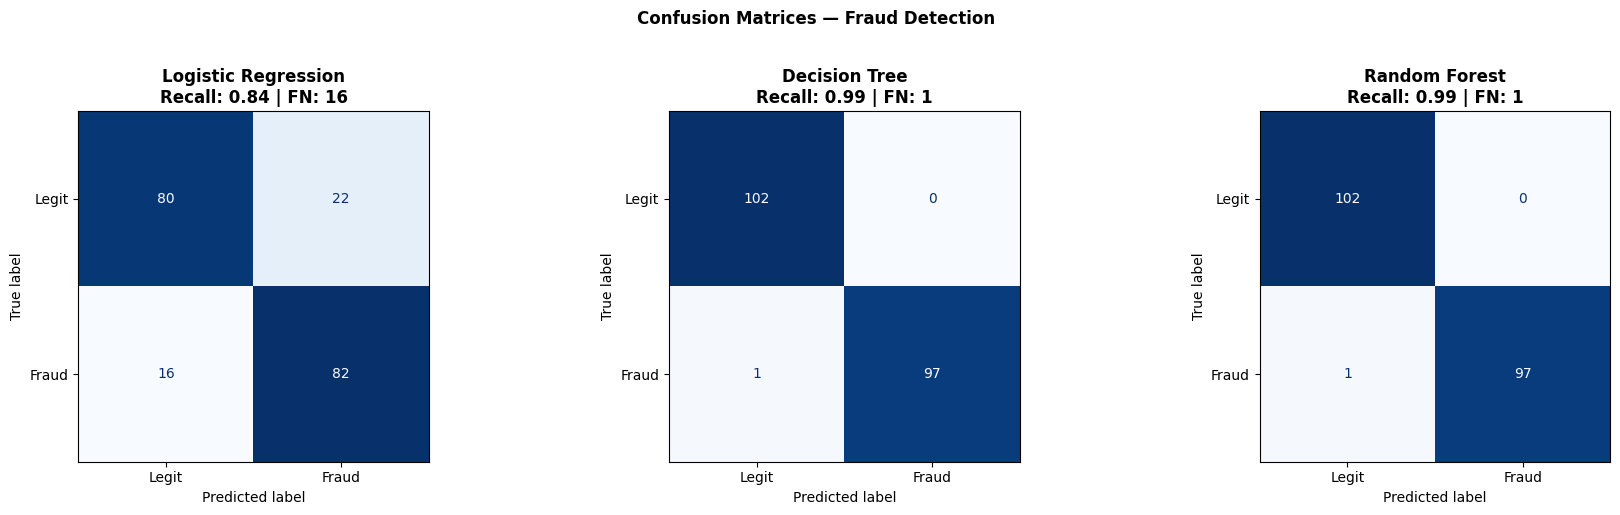

,Model,Accuracy,Precision,Recall,F1-score,FP,FN
1,Decision Tree,0.995,1.0000,0.9898,0.9949,0,1
2,Random Forest,0.995,1.0000,0.9898,0.9949,0,1
0,Logistic Regression,0.810,0.7885,0.8367,0.8119,22,16



Guide: TN=correct legit | FP=false alarm | FN=missed fraud (costly!) | TP=detected fraud


In [20]:
print("=" * 55)
print(" MODEL EVALUATION — CONFUSION MATRICES")
print("=" * 55)

fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 5))
evaluation_summary = []

for ax, (name, res) in zip(axes, results.items()):
    y_pred = res["model"].predict(X_test_selected)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    ConfusionMatrixDisplay(cm, display_labels=['Legit', 'Fraud']).plot(
        ax=ax, cmap='Blues', colorbar=False, values_format='d')

    rec = recall_score(y_test, y_pred, zero_division=0)
    f1  = f1_score(y_test, y_pred, zero_division=0)
    evaluation_summary.append({
        "Model": name,
        "Accuracy" : round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "Recall"   : round(rec, 4),
        "F1-score" : round(f1, 4),
        "FP": fp, "FN": fn
    })
    ax.set_title(f"{name}\nRecall: {rec:.2f} | FN: {fn}", fontweight='bold')

plt.suptitle("Confusion Matrices — Fraud Detection", fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

evaluation_df = pd.DataFrame(evaluation_summary)
display(evaluation_df.sort_values(by=["Recall", "F1-score"], ascending=False))

print("\nGuide: TN=correct legit | FP=false alarm | FN=missed fraud (costly!) | TP=detected fraud")

In [21]:
# Hyperparameter Tuning — GridSearchCV on Random Forest
print("=" * 60)
print(" HYPERPARAMETER TUNING — RANDOM FOREST")
print("=" * 60)

param_grid = {
    'n_estimators'    : [50, 100, 150],
    'max_depth'       : [None, 5, 10],
    'min_samples_split': [2, 5],
    'class_weight'    : [None, 'balanced']
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid, cv=3, scoring='recall', n_jobs=-1, verbose=1
)

print("\n🔍 Running GridSearchCV...")
grid_search.fit(X_train_selected, y_train)

best_model = grid_search.best_estimator_
best_pred  = best_model.predict(X_test_selected)

print("\n── Best Parameters ──────────────────────────────────")
print(grid_search.best_params_)
print(f"\n  Recall    : {recall_score(y_test, best_pred, zero_division=0):.4f}")
print(f"  F1-score  : {f1_score(y_test, best_pred, zero_division=0):.4f}")
print(f"  Precision : {precision_score(y_test, best_pred, zero_division=0):.4f}")
print(f"  Accuracy  : {accuracy_score(y_test, best_pred):.4f}")
print(f"\n🏆 Best CV Recall: {grid_search.best_score_:.4f}")

 HYPERPARAMETER TUNING — RANDOM FOREST

🔍 Running GridSearchCV...
Fitting 3 folds for each of 36 candidates, totalling 108 fits

── Best Parameters ──────────────────────────────────
{'class_weight': None, 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}

  Recall    : 0.9796
  F1-score  : 0.9897
  Precision : 1.0000
  Accuracy  : 0.9900

🏆 Best CV Recall: 0.9898


              precision    recall  f1-score   support

  Legitimate       0.98      1.00      0.99       102
  Fraudulent       1.00      0.98      0.99        98

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200



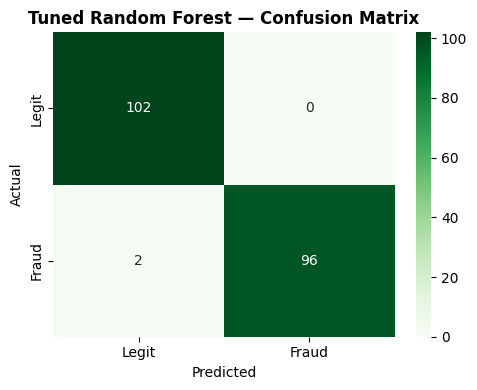

Fraud Missed (FN): 2  |  Detected (TP): 96  |  False Alarms (FP): 0
Recall    : 0.9796
ROC-AUC   : 0.9998


In [22]:
# Tuned Model — Full Evaluation
print(classification_report(y_test, best_pred, target_names=['Legitimate', 'Fraudulent']))

cm_tuned = confusion_matrix(y_test, best_pred)
tn, fp, fn, tp = cm_tuned.ravel()

plt.figure(figsize=(5, 4))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
plt.title('Tuned Random Forest — Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print(f"Fraud Missed (FN): {fn}  |  Detected (TP): {tp}  |  False Alarms (FP): {fp}")
print(f"Recall    : {tp / (tp + fn):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, best_model.predict_proba(X_test_selected)[:, 1]):.4f}")

**💡 What we did:**
- **Confusion Matrix**: Shows exact TP/FP/TN/FN counts — FN (missed fraud) is the most costly error.
- **Classification Report**: Precision, Recall, F1 per class.
- **GridSearchCV**: 3-fold CV across hyperparameter combinations — selects best without overfitting to test set.

---

## 🔬 Experiment 10: Model Deployment (Mini Implementation)
*(MLDLC Step 9)*

### Objective
Create a prediction function that takes user input and returns a fraud decision.

In [23]:
# ============================================================
# LOCK TRAINING SETUP FOR DEPLOYMENT
# ============================================================

training_columns = X_train_selected.columns.tolist()

VALID_CATEGORIES = sorted(data['Merchant_Category'].unique())
VALID_CITIES     = sorted(data['City'].unique())

THRESHOLD = 0.40

# Columns the scaler was fit on (always the original 4)
ORIGINAL_SCALE_COLS = ['Age', 'Transaction_Amount', 'Failed_Attempts', 'Hour']

# Only the ones that survived feature selection (subset used in prediction)
SCALE_COLS = [c for c in ORIGINAL_SCALE_COLS if c in training_columns]

# ============================================================
# FRAUD PREDICTION FUNCTION
# ============================================================

def predict_fraud(
    age,
    gender,
    transaction_amount,
    merchant_category,
    city,
    hour,
    month,
    international_transaction,
    card_present,
    failed_attempts,
    threshold=THRESHOLD
):

    # ── INPUT VALIDATION ────────────────────────────────────
    errors = []

    if not (1 <= int(age) <= 120):
        errors.append("Age must be between 1 and 120.")
    if gender not in ["Male", "Female"]:
        errors.append("Gender must be Male or Female.")
    if float(transaction_amount) < 0:
        errors.append("Amount cannot be negative.")
    if merchant_category not in VALID_CATEGORIES:
        errors.append(f"Category must be one of: {VALID_CATEGORIES}")
    if city not in VALID_CITIES:
        errors.append(f"City must be one of: {VALID_CITIES}")
    if not (0 <= int(hour) <= 23):
        errors.append("Hour must be between 0 and 23.")
    if not (1 <= int(month) <= 12):
        errors.append("Month must be between 1 and 12.")
    if int(international_transaction) not in [0, 1]:
        errors.append("International Transaction must be 0 or 1.")
    if int(card_present) not in [0, 1]:
        errors.append("Card Present must be 0 or 1.")
    if int(failed_attempts) < 0:
        errors.append("Failed Attempts cannot be negative.")

    if errors:
        raise ValueError("\n".join(errors))

    # ── BUILD INPUT ROW ──────────────────────────────────────
    row = {
        "Age"                      : int(age),
        "Gender"                   : 0 if gender == "Male" else 1,
        "Transaction_Amount"       : float(transaction_amount),
        "International_Transaction": int(international_transaction),
        "Card_Present"             : int(card_present),
        "Failed_Attempts"          : int(failed_attempts),
        "Hour"                     : int(hour),
        "Month"                    : int(month),
        "DayOfWeek"                : 0,
        "IsWeekend"                : 0,
        "IsNight"                  : 1 if int(hour) < 6 else 0,
    }

    input_df = pd.DataFrame([row])

    # ── ONE-HOT ENCODED COLUMNS ──────────────────────────────
    for col in training_columns:
        if col.startswith("Merchant_Category_"):
            category_name = col.replace("Merchant_Category_", "")
            input_df[col] = 1 if merchant_category == category_name else 0
        elif col.startswith("City_"):
            city_name = col.replace("City_", "")
            input_df[col] = 1 if city == city_name else 0

    # ── MATCH TRAINING COLUMN ORDER ──────────────────────────
    input_df = input_df.reindex(columns=training_columns, fill_value=0)

    # ── SCALE FEATURES (FIX: build full 4-col array for scaler) ──
    # The scaler was fit on ORIGINAL_SCALE_COLS (4 cols).
    # We must pass exactly those 4 columns; then pick only SCALE_COLS back.
    full_scale_input = pd.DataFrame(
        [[int(age), float(transaction_amount), int(failed_attempts), int(hour)]],
        columns=ORIGINAL_SCALE_COLS
    )
    scaled_values = scaler.transform(full_scale_input)[0]  # shape (4,)
    orig_to_scaled = dict(zip(ORIGINAL_SCALE_COLS, scaled_values))

    for col in SCALE_COLS:
        input_df[col] = orig_to_scaled[col]

    # ── PREDICTION ────────────────────────────────────────────
    fraud_prob = best_model.predict_proba(input_df)[0][1]
    prediction = int(fraud_prob >= threshold)

    # ── RISK LEVEL ────────────────────────────────────────────
    if   fraud_prob >= 0.70: risk = "🔴 HIGH RISK"
    elif fraud_prob >= 0.40: risk = "🟡 MEDIUM RISK"
    else:                    risk = "🟢 LOW RISK"

    return {
        "Prediction"       : "⚠️ FRAUD" if prediction else "✅ LEGITIMATE",
        "Fraud Probability": f"{fraud_prob * 100:.2f}%",
        "Legit Probability": f"{(1 - fraud_prob) * 100:.2f}%",
        "Risk Level"       : risk,
        "Threshold"        : f"{threshold * 100:.0f}%",
        "Timestamp"        : datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    }

print("✅ predict_fraud() ready!")
print(f"Valid Categories : {VALID_CATEGORIES}")
print(f"Valid Cities     : {VALID_CITIES}")

✅ predict_fraud() ready!
Valid Categories : ['Electronics', 'Entertainment', 'Fashion', 'Food', 'Fuel', 'Grocery', 'Healthcare', 'Online Shopping', 'Travel']
Valid Cities     : ['Bangalore', 'Chennai', 'Delhi', 'Gurgaon', 'Mumbai', 'Pune']


In [24]:
# ============================================================
# SAMPLE PREDICTIONS
# ============================================================

test_cases = [
    {
        "label": "High-risk",
        "age": 28, "gender": "Male", "transaction_amount": 4500.00,
        "merchant_category": "Online Shopping", "city": "Mumbai",
        "hour": 3, "month": 8,
        "international_transaction": 1, "card_present": 0, "failed_attempts": 4
    },
    {
        "label": "Low-risk",
        "age": 45, "gender": "Female", "transaction_amount": 250.00,
        "merchant_category": "Grocery", "city": "Delhi",
        "hour": 14, "month": 3,
        "international_transaction": 0, "card_present": 1, "failed_attempts": 0
    }
]

for tc in test_cases:
    label = tc["label"]                          # ✅ FIX: read without mutating
    params = {k: v for k, v in tc.items() if k != "label"}  # ✅ FIX: clean copy

    print(f"\n{'─'*50}")
    print(f"  {label}")
    print(f"{'─'*50}")

    try:
        result = predict_fraud(**params)
        for k, v in result.items():
            print(f"  {k:<22}: {v}")
    except ValueError as e:
        print(f"  ❌ Input Error: {e}")
    except Exception as e:
        print(f"  ❌ Unexpected Error: {e}")


──────────────────────────────────────────────────
  High-risk
──────────────────────────────────────────────────
  Prediction            : ⚠️ FRAUD
  Fraud Probability     : 100.00%
  Legit Probability     : 0.00%
  Risk Level            : 🔴 HIGH RISK
  Threshold             : 40%
  Timestamp             : 2026-05-18 18:58:25

──────────────────────────────────────────────────
  Low-risk
──────────────────────────────────────────────────
  Prediction            : ✅ LEGITIMATE
  Fraud Probability     : 0.00%
  Legit Probability     : 100.00%
  Risk Level            : 🟢 LOW RISK
  Threshold             : 40%
  Timestamp             : 2026-05-18 18:58:25


In [25]:
# ============================================================
# INTERACTIVE FRAUD PREDICTION SYSTEM
# ============================================================
print("=" * 60)
print("   INTERACTIVE FRAUD PREDICTION SYSTEM")
print("=" * 60)

while True:
    print("\nEnter transaction details:\n")
    try:
        age    = input("  Age (1–120)                        : ")
        gender = input("  Gender (Male / Female)             : ").strip().title()
        amount = input("  Transaction Amount                 : ")
        merc   = input("  Merchant Category                  : ").strip()
        city   = input("  City                               : ").strip()
        hour   = input("  Transaction Hour (0–23)            : ")
        month  = input("  Month (1–12)                       : ")
        intl   = input("  International Transaction (0 / 1)  : ")
        card   = input("  Card Present (0 / 1)               : ")
        fails  = input("  Failed Attempts                    : ")
    except (KeyboardInterrupt, EOFError, OSError):   # ✅ FIX: catch Kaggle's StdinNotImplementedError
        print("\n✅ System closed."); break

    try:
        result = predict_fraud(
            age=age, gender=gender, transaction_amount=amount,
            merchant_category=merc, city=city, hour=hour, month=month,
            international_transaction=intl, card_present=card, failed_attempts=fails
        )
        print("\n" + "─" * 50)
        for k, v in result.items():
            print(f"  {k:<22}: {v}")
        print("─" * 50)
    except ValueError as e:
        print(f"  ❌ Input Error: {e}")
    except Exception as e:
        print(f"  ❌ Unexpected Error: {e}")
        continue                                     # ✅ FIX: skip "Another prediction?" on crash

    try:
        if input("\nAnother prediction? (y / n) : ").strip().lower() != "y":
            print("\n✅ System closed."); break
    except (KeyboardInterrupt, EOFError, OSError):   # ✅ FIX: same catch
        break

   INTERACTIVE FRAUD PREDICTION SYSTEM

Enter transaction details:



  Age (1–120)                        :  24
  Gender (Male / Female)             :  Male
  Transaction Amount                 :  2400
  Merchant Category                  :  Food
  City                               :  Delhi
  Transaction Hour (0–23)            :  19
  Month (1–12)                       :  2
  International Transaction (0 / 1)  :  0
  Card Present (0 / 1)               :  1
  Failed Attempts                    :  1



──────────────────────────────────────────────────
  Prediction            : ✅ LEGITIMATE
  Fraud Probability     : 1.00%
  Legit Probability     : 99.00%
  Risk Level            : 🟢 LOW RISK
  Threshold             : 40%
  Timestamp             : 2026-05-18 18:59:26
──────────────────────────────────────────────────



Another prediction? (y / n) :  n



✅ System closed.


In [26]:
# Save Model & Scaler  
pickle.dump(best_model, open("model.pkl", "wb"))
pickle.dump(scaler,     open("scaler.pkl", "wb"))
print("✅ model.pkl saved")
print("✅ scaler.pkl saved")

✅ model.pkl saved
✅ scaler.pkl saved


**💡 What we built:**
- `predict_fraud()` handles full preprocessing (encode → align → scale → predict) in one call.
- Returns binary prediction + fraud probability + risk tier.
- Interactive loop for real-time transaction testing.

---

## 📋 Final Summary

| Experiment | Topic | Status |
|---|---|---|
| 1 | Problem Definition | ✅ |
| 2 | Dataset Structure | ✅ |
| 3 | Problem Type | ✅ |
| 4 | Data Cleaning | ✅ |
| 5 | Preprocessing | ✅ |
| 6 | EDA | ✅ |
| 7 | Feature Selection | ✅ |
| 8 | Model Training | ✅ |
| 9 | Evaluation & Tuning | ✅ |
| 10 | Deployment | ✅ |

**Best Model**: Tuned Random Forest (GridSearchCV) — highest Recall & F1-score.
